In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
comparison = pd.DataFrame([
    {
        "Model": "KNN",
        "Type": "Traditional ML",
        "Accuracy": 89.10,
        "Macro Precision": 89.95,
        "Macro Recall": 90.40,
        "Macro F1": 89.86
    },

    {
        "Model": "Random Forest",
        "Type": "Traditional ML",
        "Accuracy": 88.70,
        "Macro Precision": 89.88,
        "Macro Recall": 89.74,
        "Macro F1": 89.65
    },

    {
        "Model": "Logistic Regression",
        "Type": "Traditional ML",
        "Accuracy": 90.90,
        "Macro Precision": 91.18,
        "Macro Recall": 91.82,
        "Macro F1": 91.35
    },

    {
        "Model": "Decision Tree",
        "Type": "Traditional ML",
        "Accuracy": 66.70,
        "Macro Precision": 68.70,
        "Macro Recall": 68.00,
        "Macro F1": 67.14
    },

    {
    "Model": "EfficientNetB7",
    "Type": "Deep Learning",
    "Accuracy": 92.30,
    "Macro Precision": 93.50,
    "Macro Recall": 93.06,
    "Macro F1": 93.19
}
])

In [3]:
ranking = comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

ranking.insert(
    0,
    "Rank",
    range(1, len(ranking) + 1)
)

ranking

,Rank,Model,Type,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,EfficientNetB7,Deep Learning,92.3,93.50,93.06,93.19
1,2,Logistic Regression,Traditional ML,90.9,91.18,91.82,91.35
2,3,KNN,Traditional ML,89.1,89.95,90.40,89.86
3,4,Random Forest,Traditional ML,88.7,89.88,89.74,89.65
4,5,Decision Tree,Traditional ML,66.7,68.70,68.00,67.14


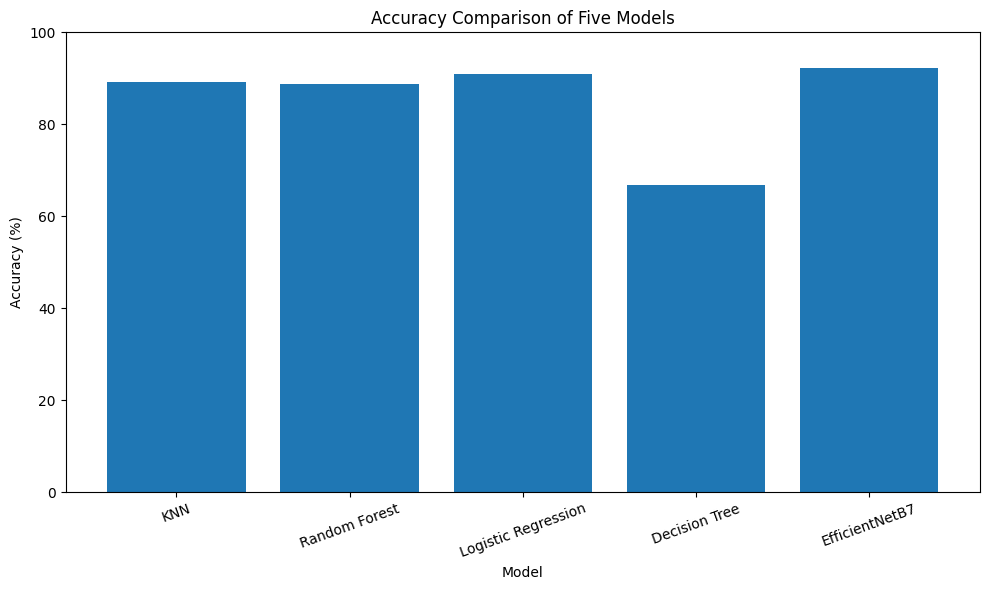

In [4]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title(
    "Accuracy Comparison of Five Models"
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [5]:
import os

results_dir = "/content/drive/MyDrive/BRISC_ML_Project/results"

os.makedirs(results_dir, exist_ok=True)

print("Results folder:", results_dir)

Results folder: /content/drive/MyDrive/BRISC_ML_Project/results


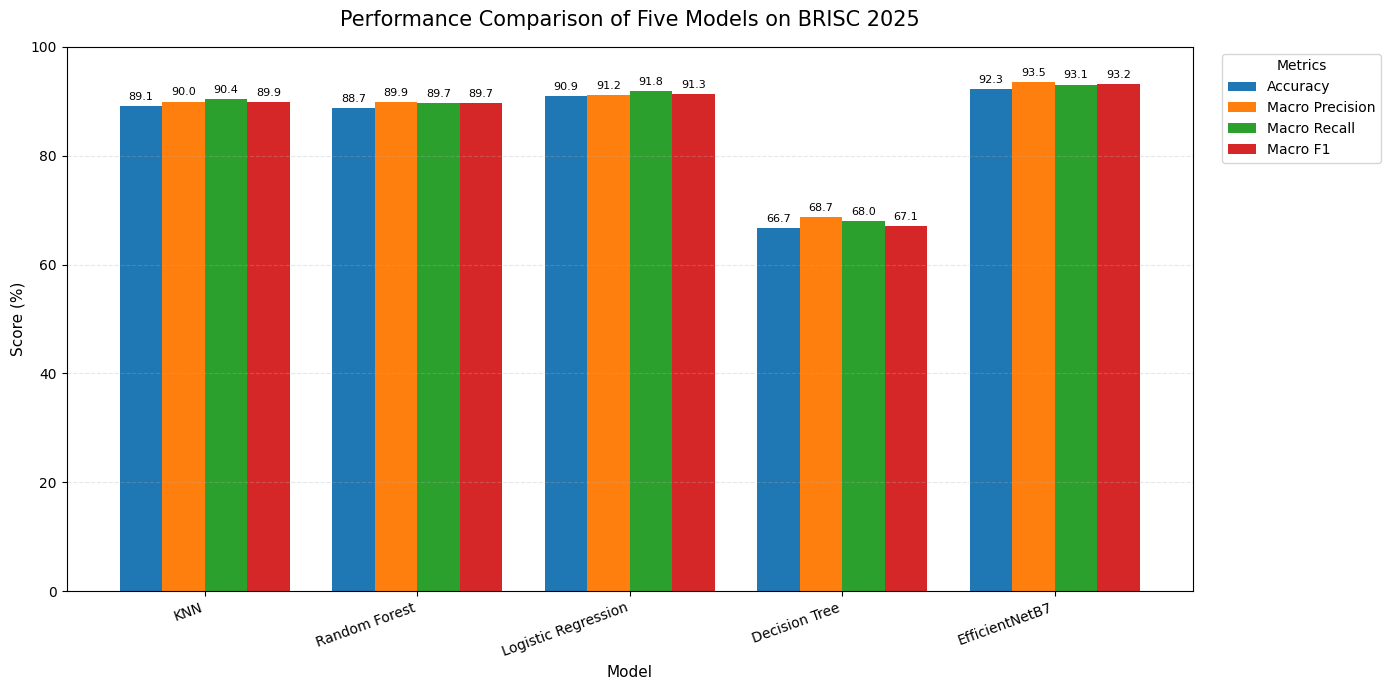

Final comparison graph saved successfully!


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))

plot_data = comparison.set_index("Model")[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

plot_data.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

ax.set_title(
    "Performance Comparison of Five Models on BRISC 2025",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Score (%)", fontsize=11)

ax.set_ylim(0, 100)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=20,
    ha="right"
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=8
    )

# Legend outside the graph
ax.legend(
    title="Metrics",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/BRISC_ML_Project/results/final_5_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final comparison graph saved successfully!")


In [7]:
best_model = comparison.loc[
    comparison["Macro F1"].idxmax()
]

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    best_model["Accuracy"],
    "%"
)

print(
    "Macro F1:",
    best_model["Macro F1"],
    "%"
)

Best Model: EfficientNetB7
Accuracy: 92.3 %
Macro F1: 93.19 %


In [8]:
best_accuracy = comparison["Accuracy"].max()

comparison["Accuracy Gap from Best"] = (
    best_accuracy - comparison["Accuracy"]
).round(2)

comparison

,Model,Type,Accuracy,Macro Precision,Macro Recall,Macro F1,Accuracy Gap from Best
0,KNN,Traditional ML,89.1,89.95,90.40,89.86,3.2
1,Random Forest,Traditional ML,88.7,89.88,89.74,89.65,3.6
2,Logistic Regression,Traditional ML,90.9,91.18,91.82,91.35,1.4
3,Decision Tree,Traditional ML,66.7,68.70,68.00,67.14,25.6
4,EfficientNetB7,Deep Learning,92.3,93.50,93.06,93.19,0.0


In [9]:
traditional_ml = comparison[
    comparison["Type"] == "Traditional ML"
]

deep_learning = comparison[
    comparison["Type"] == "Deep Learning"
]

print("Traditional ML models:")
print(traditional_ml)

print("\nDeep Learning model:")
print(deep_learning)

Traditional ML models:
                 Model            Type  Accuracy  Macro Precision  \
0                  KNN  Traditional ML      89.1            89.95   
1        Random Forest  Traditional ML      88.7            89.88   
2  Logistic Regression  Traditional ML      90.9            91.18   
3        Decision Tree  Traditional ML      66.7            68.70   

   Macro Recall  Macro F1  Accuracy Gap from Best  
0         90.40     89.86                     3.2  
1         89.74     89.65                     3.6  
2         91.82     91.35                     1.4  
3         68.00     67.14                    25.6  

Deep Learning model:
            Model           Type  Accuracy  Macro Precision  Macro Recall  \
4  EfficientNetB7  Deep Learning      92.3             93.5         93.06   

   Macro F1  Accuracy Gap from Best  
4     93.19                     0.0  


In [10]:
traditional_mean = traditional_ml[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].mean()

print(
    "Traditional ML Average Performance:"
)

print(traditional_mean)

Traditional ML Average Performance:
Accuracy           83.8500
Macro Precision    84.9275
Macro Recall       84.9900
Macro F1           84.5000
dtype: float64


In [11]:
best_traditional = traditional_ml.loc[
    traditional_ml["Macro F1"].idxmax()
]

efficientnet = deep_learning.iloc[0]

print(
    "Best Traditional ML:",
    best_traditional["Model"]
)

print(
    "Best Traditional ML Macro F1:",
    best_traditional["Macro F1"],
    "%"
)

print(
    "EfficientNetB7 Macro F1:",
    efficientnet["Macro F1"],
    "%"
)

print(
    "Difference:",
    round(
        best_traditional["Macro F1"]
        - efficientnet["Macro F1"],
        2
    ),
    "percentage points"
)

Best Traditional ML: Logistic Regression
Best Traditional ML Macro F1: 91.35 %
EfficientNetB7 Macro F1: 93.19 %
Difference: -1.84 percentage points


In [12]:
os.makedirs("../results", exist_ok=True)

comparison.to_csv(
    "../results/final_5_model_comparison.csv",
    index=False
)

print(
    "Final comparison CSV saved."
)

Final comparison CSV saved.


In [13]:
ranking.to_csv(
    "../results/final_model_ranking.csv",
    index=False
)

print(
    "Ranking saved."
)

Ranking saved.
